In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("kpk_engineering_programs.csv")
df.head()

,Program,PEC_Level,Research_Output,Student_Faculty_Ratio,PhD_Percentage,Program_Diversity,University_Age,Location_Type,Industry_Linkages,Employability_Rate
0,University of Swat - Chemical Engineering,1,4.22,12.4,28.5,2,5,2,6.2,40.0
1,Pak-Austria Fachhochschule - Mining Engineering,3,3.85,11.1,56.0,6,15,2,4.1,40.0
2,City University Peshawar - Electrical Engineering,3,1.08,18.9,36.0,7,23,1,5.9,40.0
3,CECOS University - Telecom Engineering,2,3.33,13.7,58.0,4,12,3,2.1,40.0
4,UEAS Swat - Software Engineering,2,3.57,16.3,52.4,5,12,3,1.0,40.0


In [5]:
target = 'Employability_Rate'
features = ['PEC_Level', 'Research_Output', 'Student_Faculty_Ratio', 'PhD_Percentage',
            'Program_Diversity', 'University_Age', 'Location_Type', 'Industry_Linkages']

X = df[features].values      # features as numbers
y = df[target].values

Simple Linear Regression

In [6]:
simple_feature = 'University_Age'
X_simple = df[[simple_feature]].values

# Add column of 1s (for intercept)
X_simple_b = np.c_[np.ones(X_simple.shape[0]), X_simple]

# Train model (super simple math!)
theta_simple = np.linalg.lstsq(X_simple_b, y, rcond=None)[0]

y_pred_simple = X_simple_b @ theta_simple

In [7]:
ss_res = np.sum((y - y_pred_simple)**2)
ss_tot = np.sum((y - y.mean())**2)
r2_simple = 1 - (ss_res / ss_tot)
print(f"\nR² of simple regression: {r2_simple:.4f}")


R² of simple regression: 0.1494


Multiple Linear Regression

In [9]:
X_b = np.c_[np.ones(X.shape[0]), X]        # add intercept column
theta = np.linalg.lstsq(X_b, y, rcond=None)[0]   # train model

y_pred_multi = X_b @ theta



In [11]:
# Calculate R²
ss_res_m = np.sum((y - y_pred_multi)**2)
r2_multi = 1 - (ss_res_m / ss_tot)
print(f"R² of multiple regression: {r2_multi:.4f}")

R² of multiple regression: 0.4292


In [12]:
coef = dict(zip(features, theta[1:]))   # ignore intercept

print("\nWhich feature has the largest positive coefficient?")
max_f = max(coef, key=coef.get)
print(f"   → {max_f} ({coef[max_f]:.4f})")

print("\nWhich feature has the largest negative coefficient?")
min_f = min(coef, key=coef.get)
print(f"   → {min_f} ({coef[min_f]:.4f})")

print(f"\nInterpret the coefficient of PEC_Level: {coef['PEC_Level']:.4f}")
print("   → When PEC_Level goes up by 1, Employability_Rate drops by about 1.23 points (everything else same)")


Which feature has the largest positive coefficient?
   → Research_Output (0.3458)

Which feature has the largest negative coefficient?
   → PEC_Level (-1.2294)

Interpret the coefficient of PEC_Level: -1.2294
   → When PEC_Level goes up by 1, Employability_Rate drops by about 1.23 points (everything else same)


In [13]:
uet_row = df[df['Program'] == 'UET Peshawar - Civil Engineering'].iloc[0]
x_uet = np.array([1] + [uet_row[f] for f in features])   # add 1 for intercept
predicted = x_uet @ theta
print(f"\nPredicted employability for UET Peshawar - Civil Engineering: {predicted:.2f}")


Predicted employability for UET Peshawar - Civil Engineering: 42.75


In [14]:
mse_simple = np.mean((y - y_pred_simple)**2)
mse_multi = np.mean((y - y_pred_multi)**2)
improvement = ((mse_simple - mse_multi) / mse_simple) * 100
print(f"MSE improvement percentage: {improvement:.1f}%")

MSE improvement percentage: 32.9%


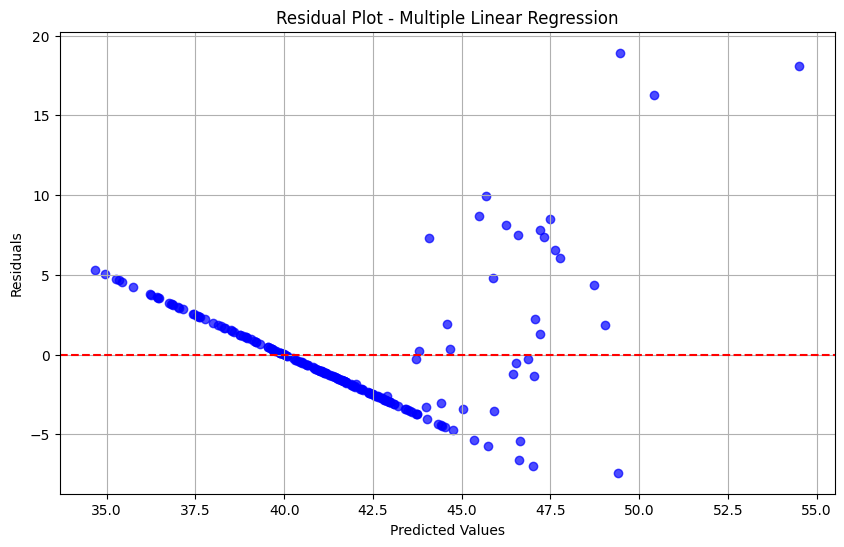


Residual plot interpretation: Points are randomly scattered around the zero line with no pattern or funnel shape.
This means our linear model is working well!


In [15]:
residuals = y - y_pred_multi

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_multi, residuals, alpha=0.7, color='blue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Linear Regression')
plt.grid(True)
plt.show()

print("\nResidual plot interpretation: Points are randomly scattered around the zero line with no pattern or funnel shape.")
print("This means our linear model is working well!")